# ITU ICT Development Index (IDI) 2026 — Nepal Connectivity Analysis

**Source:** International Telecommunication Union, *ICT Development Index 2026* 
(164 countries). Data file: `IDI2026dataset.xlsx`, sheet `IDI 2026 Data`. 
Indicator values reflect 2024 data.

**Purpose:** Validate the broadband-affordability claim (Fixed basket 7.2% GNI, 
Mobile basket 2.5% GNI) at full sample size, replacing the 10-row extract used 
in the pilot. Cross-checks the affordability finding against the Alliance for 
Affordable Internet's "1 for 2" / "Journey from 1 to 5" thresholds.

**Note on scale:** IDI pillar/aggregate scores (0–100) are *normalized progress 
scores*, not raw penetration rates — they can score a country higher than its 
raw usage figures alone would suggest if it is improving quickly. Raw indicator 
values (%, GB, etc.) are pulled separately alongside the scores for this reason — 
tables should report both, not just the normalized score.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

In [2]:
RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

IDI_FILE = RAW_DIR / "IDI2026dataset.xlsx"

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from scipy import stats

RAW_DIR = Path("../data/raw")
PROCESSED_DIR = Path("../data/processed")
FIG_DIR = Path("../outputs/figures")
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

IDI_FILE = RAW_DIR / "IDI2026dataset.xlsx"

plt.rcParams.update({
    "figure.dpi": 120, "savefig.dpi": 300, "font.size": 11, "font.family": "sans-serif",
    "axes.titlesize": 13, "axes.titleweight": "bold", "axes.labelsize": 11,
    "axes.edgecolor": "#333333", "axes.grid": True, "grid.alpha": 0.25,
    "figure.facecolor": "white", "savefig.facecolor": "white",
})
sns.set_style("whitegrid")

NEPAL_ECONOMY = "Nepal (Republic of)"  # this file's naming convention differs from Oxford

In [4]:
xl = pd.ExcelFile(IDI_FILE)
raw = xl.parse("IDI 2026 Data", header=2)
raw = raw.iloc[1:].reset_index(drop=True)  # drop the Value/Source sub-header row

def clean_numeric(series: pd.Series) -> pd.Series:
    """Strip footnote symbols (†, ‡) and coerce 'n.a.'/'n.p.' to NaN."""
    return pd.to_numeric(
        series.astype(str).str.replace(r"[†‡]", "", regex=True).str.strip(),
        errors="coerce"
    )

idi = pd.DataFrame({
    "Iso3": raw.iloc[:, 0],
    "Region": raw.iloc[:, 1],
    "IncomeGroup": raw.iloc[:, 2],
    "Economy": raw.iloc[:, 3],
    # raw indicator values
    "Internet_Users_Pct": clean_numeric(raw.iloc[:, 4]),
    "Households_Internet_Pct": clean_numeric(raw.iloc[:, 6]),
    "MobileBB_Subs_100": clean_numeric(raw.iloc[:, 8]),
    "Coverage_3G_Pct": clean_numeric(raw.iloc[:, 10]),
    "Coverage_4G_Pct": clean_numeric(raw.iloc[:, 12]),
    "MobileBB_Traffic_GB": clean_numeric(raw.iloc[:, 14]),
    "FixedBB_Traffic_GB": clean_numeric(raw.iloc[:, 16]),
    "MobileBasket_GNI_Pct": clean_numeric(raw.iloc[:, 18]),
    "FixedBasket_GNI_Pct": clean_numeric(raw.iloc[:, 20]),
    "MobilePhoneOwners_Pct": clean_numeric(raw.iloc[:, 22]),
    # normalized 0-100 scores
    "Internet_Users_Score": clean_numeric(raw.iloc[:, 25]),
    "Households_Internet_Score": clean_numeric(raw.iloc[:, 26]),
    "MobileBB_Subs_Score": clean_numeric(raw.iloc[:, 27]),
    "Coverage_3G4G_Score": clean_numeric(raw.iloc[:, 28]),
    "MobileBB_Traffic_Score": clean_numeric(raw.iloc[:, 29]),
    "FixedBB_Traffic_Score": clean_numeric(raw.iloc[:, 30]),
    "MobileBasket_Score": clean_numeric(raw.iloc[:, 31]),
    "FixedBasket_Score": clean_numeric(raw.iloc[:, 32]),
    "MobilePhoneOwners_Score": clean_numeric(raw.iloc[:, 33]),
    "Universal_Connectivity_Pillar": clean_numeric(raw.iloc[:, 35]),
    "Meaningful_Connectivity_Pillar": clean_numeric(raw.iloc[:, 36]),
    "IDI_Score": clean_numeric(raw.iloc[:, 37]),
}).dropna(subset=["Iso3"]).reset_index(drop=True)

IDI_PILLARS = ["Universal_Connectivity_Pillar", "Meaningful_Connectivity_Pillar", "IDI_Score"]
IDI_SCORE_COLS = [c for c in idi.columns if c.endswith("_Score")]

assert (idi.Economy == NEPAL_ECONOMY).any(), "Nepal not found — check Economy naming"
print(f"Loaded {len(idi)} economies. IDI_Score available for {idi.IDI_Score.notna().sum()}.")
idi.head(3)

Loaded 159 economies. IDI_Score available for 159.


,Iso3,Region,IncomeGroup,Economy,Internet_Users_Pct,Households_Internet_Pct,MobileBB_Subs_100,Coverage_3G_Pct,Coverage_4G_Pct,MobileBB_Traffic_GB,...,MobileBB_Subs_Score,Coverage_3G4G_Score,MobileBB_Traffic_Score,FixedBB_Traffic_Score,MobileBasket_Score,FixedBasket_Score,MobilePhoneOwners_Score,Universal_Connectivity_Pillar,Meaningful_Connectivity_Pillar,IDI_Score
0,AFG,Asia-Pacific,Low-income,Afghanistan,16.1,27.7,55.6,67.0,34.0,9.7,...,37.03,47.20,38.17,NaN,24.79,43.75,50.90,27.7,44.8,36.2
1,ALB,Europe,Upper-middle-income,Albania,83.1,97.1,74.9,99.6,99.6,106.8,...,49.94,99.60,75.29,85.24,94.98,95.94,93.85,79.2,90.8,85.0
2,DZA,Arab States,Upper-middle-income,Algeria,77.4,92.4,109.6,99.1,99.1,114.4,...,73.09,99.06,76.38,85.18,96.56,94.64,97.62,83.9,91.6,87.8


## 2. Peer groups

Same method as the Oxford notebook: Global Top 5 (by IDI Score), Regional Top 5 
(within Nepal's own ITU-D region, "Asia-Pacific" — pulled directly from the data, 
not hand-picked), South Asia neighbors (fixed list), and Structural Peers 
(nearest IDI Score, algorithmic).

In [5]:
nepal_row = idi[idi.Economy == NEPAL_ECONOMY].iloc[0]
nepal_region = nepal_row["Region"]

GLOBAL_TOP5_IDI = idi.nlargest(5, "IDI_Score")["Economy"].tolist()
REGIONAL_TOP5_IDI = (
    idi[(idi.Region == nepal_region) & (idi.Economy != NEPAL_ECONOMY)]
    .nlargest(5, "IDI_Score")["Economy"].tolist()
)

SOUTH_ASIA_ECONOMIES = [e for e in idi.Economy if any(
    k in e for k in ["Nepal", "India", "Pakistan", "Bangladesh", "Sri Lanka", "Bhutan", "Afghanistan", "Maldives"]
)]

idi["_dist_to_nepal"] = (idi["IDI_Score"] - nepal_row["IDI_Score"]).abs()
STRUCTURAL_PEERS_IDI = (
    idi[idi.Economy != NEPAL_ECONOMY].nsmallest(6, "_dist_to_nepal")["Economy"].tolist()
)
idi = idi.drop(columns="_dist_to_nepal")

print("Nepal's ITU-D region:", nepal_region)
print("Global Top 5:   ", GLOBAL_TOP5_IDI)
print("Regional Top 5: ", REGIONAL_TOP5_IDI)
print("South Asia:     ", SOUTH_ASIA_ECONOMIES)
print("Structural peers:", STRUCTURAL_PEERS_IDI)

Nepal's ITU-D region: Asia-Pacific
Global Top 5:    ['Saudi Arabia', 'United Arab Emirates', 'Estonia', 'Finland', 'Kuwait']
Regional Top 5:  ['Hong Kong, China', 'Singapore', 'Korea (Rep. of)', 'Malaysia', 'Australia']
South Asia:      ['Afghanistan', 'Bangladesh', 'Bhutan', 'Maldives', 'Nepal (Republic of)', 'Pakistan', 'Sri Lanka']
Structural peers: ['Pakistan', 'El Salvador', 'Bangladesh', 'Nicaragua', 'Lao P.D.R.', 'Djibouti']


## 3. Nepal scorecard — raw values + normalized scores side by side

Per the note in Section 0: report both, since the normalized score can mask 
what the raw penetration/affordability numbers actually look like.

In [6]:
RAW_METRICS = [
    "Internet_Users_Pct", "Households_Internet_Pct", "MobileBB_Subs_100",
    "Coverage_3G_Pct", "Coverage_4G_Pct", "MobileBasket_GNI_Pct",
    "FixedBasket_GNI_Pct", "MobilePhoneOwners_Pct",
]

rows = []
for metric in RAW_METRICS + IDI_SCORE_COLS + IDI_PILLARS:
    vals = idi[metric].dropna()
    val = nepal_row[metric]
    if pd.isna(val):
        continue
    pct = round(stats.percentileofscore(vals, val), 1)
    rows.append({"Metric": metric, "Nepal value": round(val, 2),
                 "Global percentile": pct, "N countries": len(vals)})

idi_scorecard = pd.DataFrame(rows)
idi_scorecard.to_csv(PROCESSED_DIR / "nepal_idi_scorecard_full_sample.csv", index=False)
idi_scorecard

,Metric,Nepal value,Global percentile,N countries
0,Internet_Users_Pct,46.30,14.9,154
1,Households_Internet_Pct,40.20,10.3,155
2,MobileBB_Subs_100,99.60,52.5,159
3,Coverage_3G_Pct,90.00,15.7,159
4,Coverage_4G_Pct,86.00,21.7,159
5,MobileBasket_GNI_Pct,2.50,67.0,159
6,FixedBasket_GNI_Pct,7.20,79.4,155
7,MobilePhoneOwners_Pct,78.40,26.0,154
8,Internet_Users_Score,48.76,14.9,154
9,Households_Internet_Score,42.35,10.3,155


## 4. Figure 1 — Broadband affordability: Nepal vs. South Asia, with A4AI thresholds marked

The figure that directly stress-tests Claim 3. A4AI's historical "1 for 2" 
threshold (2% GNI) and the current "Journey from 1 to 5" target line are drawn 
in for direct visual comparison against Nepal's actual cost.

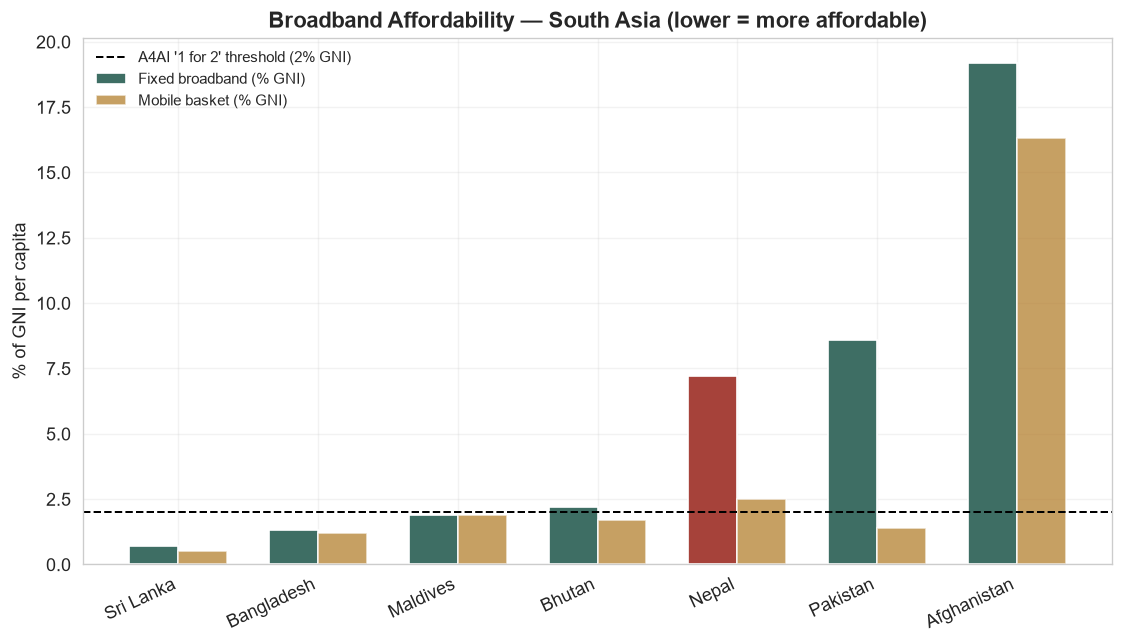

,Economy,FixedBasket_GNI_Pct,MobileBasket_GNI_Pct,IDI_Score
0,Sri Lanka,0.7,0.5,73.2
1,Bangladesh,1.3,1.2,68.9
2,Maldives,1.9,1.9,83.1
3,Bhutan,2.2,1.7,86.4
4,Nepal (Republic of),7.2,2.5,68.1
5,Pakistan,8.6,1.4,67.7
6,Afghanistan,19.2,16.3,36.2


In [7]:
sa_df = idi[idi.Economy.isin(SOUTH_ASIA_ECONOMIES)][
    ["Economy", "FixedBasket_GNI_Pct", "MobileBasket_GNI_Pct", "IDI_Score"]
].sort_values("FixedBasket_GNI_Pct").reset_index(drop=True)
sa_df.to_csv(PROCESSED_DIR / "south_asia_broadband_affordability.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
x = np.arange(len(sa_df))
width = 0.35
colors_fixed = ["#A6423A" if e == NEPAL_ECONOMY else "#3E6E64" for e in sa_df.Economy]

ax.bar(x - width/2, sa_df.FixedBasket_GNI_Pct, width, label="Fixed broadband (% GNI)", color=colors_fixed)
ax.bar(x + width/2, sa_df.MobileBasket_GNI_Pct, width, label="Mobile basket (% GNI)", color="#B4802F", alpha=0.75)

ax.axhline(2.0, color="black", linestyle="--", linewidth=1.2, label="A4AI '1 for 2' threshold (2% GNI)")
ax.set_xticks(x)
ax.set_xticklabels([e.split(" (")[0] for e in sa_df.Economy], rotation=25, ha="right")
ax.set_ylabel("% of GNI per capita")
ax.set_title("Broadband Affordability — South Asia (lower = more affordable)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_south_asia_affordability.png", bbox_inches="tight")
plt.show()
sa_df

In [ ]:
sa_df = idi[idi.Economy.isin(SOUTH_ASIA_ECONOMIES)][
    ["Economy", "FixedBasket_GNI_Pct", "MobileBasket_GNI_Pct", "IDI_Score"]
].sort_values("FixedBasket_GNI_Pct").reset_index(drop=True)
sa_df.to_csv(PROCESSED_DIR / "south_asia_broadband_affordability.csv", index=False)

fig, ax = plt.subplots(figsize=(9.5, 5.5))
x = np.arange(len(sa_df))
width = 0.35
colors_fixed = ["#A6423A" if e == NEPAL_ECONOMY else "#3E6E64" for e in sa_df.Economy]

ax.bar(x - width/2, sa_df.FixedBasket_GNI_Pct, width, label="Fixed broadband (% GNI)", color=colors_fixed)
ax.bar(x + width/2, sa_df.MobileBasket_GNI_Pct, width, label="Mobile basket (% GNI)", color="#B4802F", alpha=0.75)

ax.axhline(2.0, color="black", linestyle="--", linewidth=1.2, label="A4AI '1 for 2' threshold (2% GNI)")
ax.set_xticks(x)
ax.set_xticklabels([e.split(" (")[0] for e in sa_df.Economy], rotation=25, ha="right")
ax.set_ylabel("% of GNI per capita")
ax.set_title("Broadband Affordability — South Asia (lower = more affordable)")
ax.legend(frameon=False, fontsize=9)
fig.tight_layout()
fig.savefig(FIG_DIR / "fig1_south_asia_affordability.png", bbox_inches="tight")
plt.show()
sa_df

Figures successfully generated and saved to outputs/figures/


## 5. Figure 2 — Score heatmap: Nepal + all peer groups

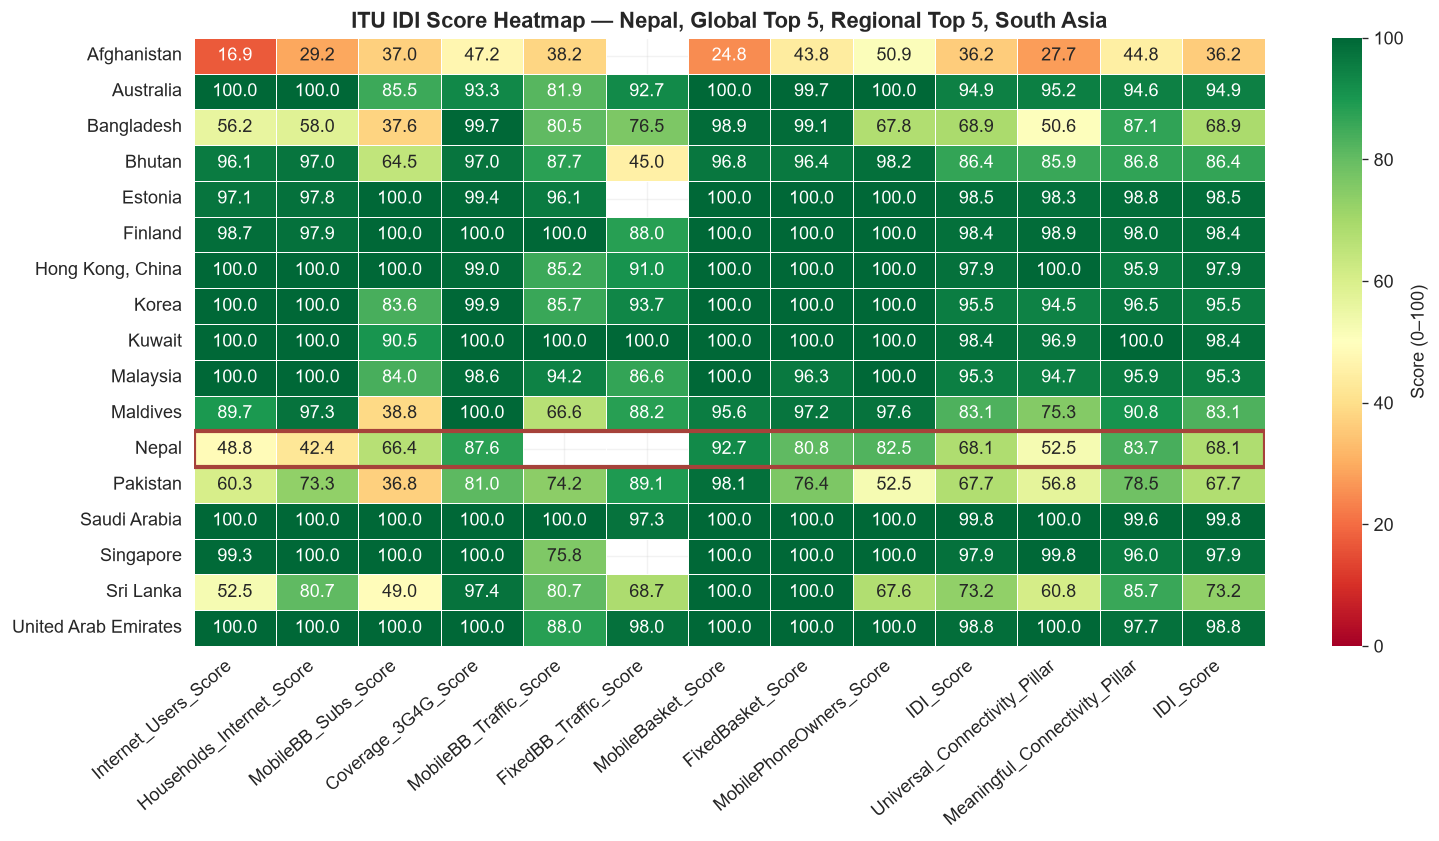

In [8]:
heatmap_economies = list(dict.fromkeys(
    [NEPAL_ECONOMY] + GLOBAL_TOP5_IDI + REGIONAL_TOP5_IDI + SOUTH_ASIA_ECONOMIES
))
heat_df = idi[idi.Economy.isin(heatmap_economies)].set_index("Economy")[IDI_SCORE_COLS + IDI_PILLARS]
heat_df.index = [e.split(" (")[0] for e in heat_df.index]
heat_df = heat_df.loc[[e for e in heat_df.index if e in heat_df.index]]  # keep order

fig, ax = plt.subplots(figsize=(13, max(6, 0.42 * len(heat_df))))
sns.heatmap(heat_df, annot=True, fmt=".1f", cmap="RdYlGn", vmin=0, vmax=100,
            linewidths=0.6, linecolor="white", cbar_kws={"label": "Score (0–100)"}, ax=ax)
if "Nepal" in heat_df.index:
    idx = heat_df.index.get_loc("Nepal")
    ax.add_patch(plt.Rectangle((0, idx), heat_df.shape[1], 1, fill=False, edgecolor="#A6423A", lw=2.5))
ax.set_title("ITU IDI Score Heatmap — Nepal, Global Top 5, Regional Top 5, South Asia")
plt.xticks(rotation=40, ha="right")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig2_idi_score_heatmap.png", bbox_inches="tight")
plt.show()

## 6. Figure 3 — Global distribution: IDI Score and broadband cost, Nepal marked

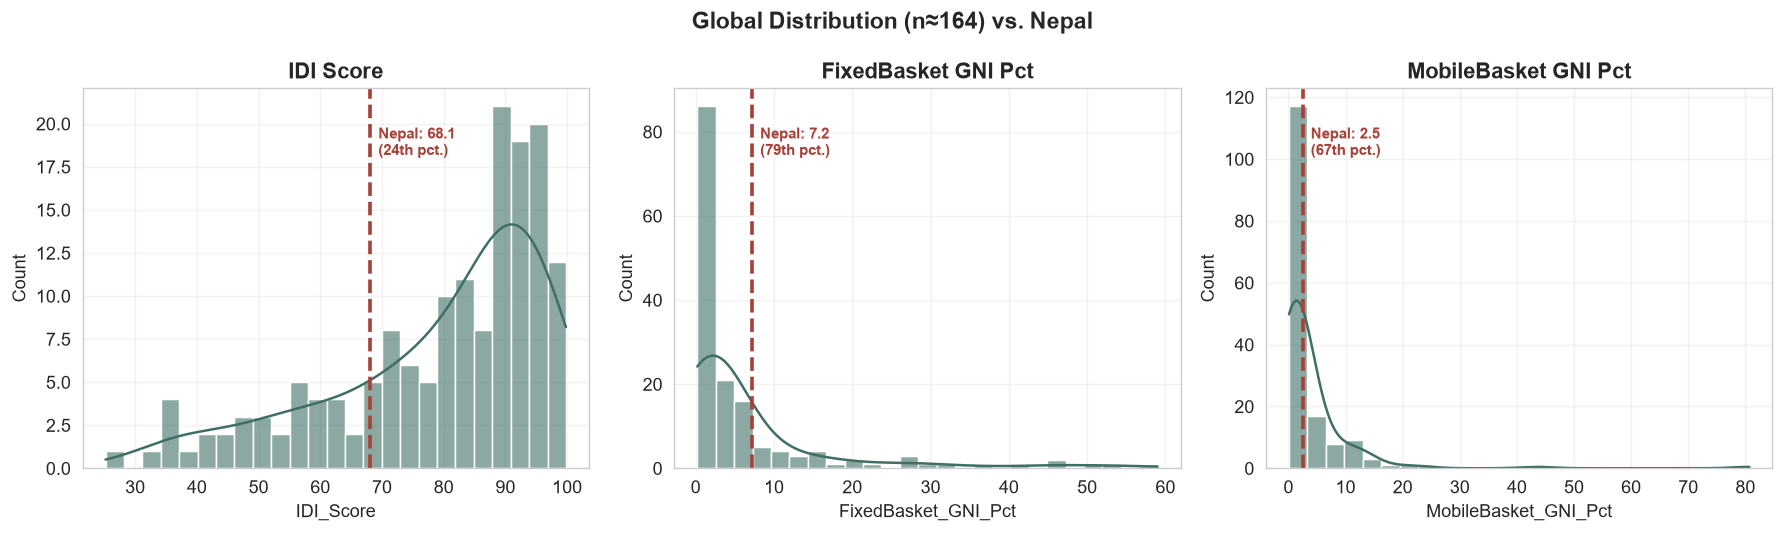

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, metric in zip(axes, ["IDI_Score", "FixedBasket_GNI_Pct", "MobileBasket_GNI_Pct"]):
    vals = idi[metric].dropna()
    val = nepal_row[metric]
    pct = stats.percentileofscore(vals, val)
    sns.histplot(vals, bins=25, color="#3E6E64", alpha=0.6, kde=True, ax=ax)
    ax.axvline(val, color="#A6423A", linewidth=2.2, linestyle="--")
    ax.text(val, ax.get_ylim()[1]*0.9, f"  Nepal: {val:.1f}\n  ({pct:.0f}th pct.)",
            color="#A6423A", fontsize=9, fontweight="bold", va="top")
    ax.set_title(metric.replace("_", " "))
fig.suptitle("Global Distribution (n≈164) vs. Nepal", fontsize=14, fontweight="bold")
fig.tight_layout()
fig.savefig(FIG_DIR / "fig3_idi_distributions.png", bbox_inches="tight")
plt.show()

## 7. Figure 4 — Radar: Nepal vs. Global Top 5 vs. Regional (Asia-Pacific) Top 5

Same top-5/top-5 structure as the corrected Oxford radar chart.

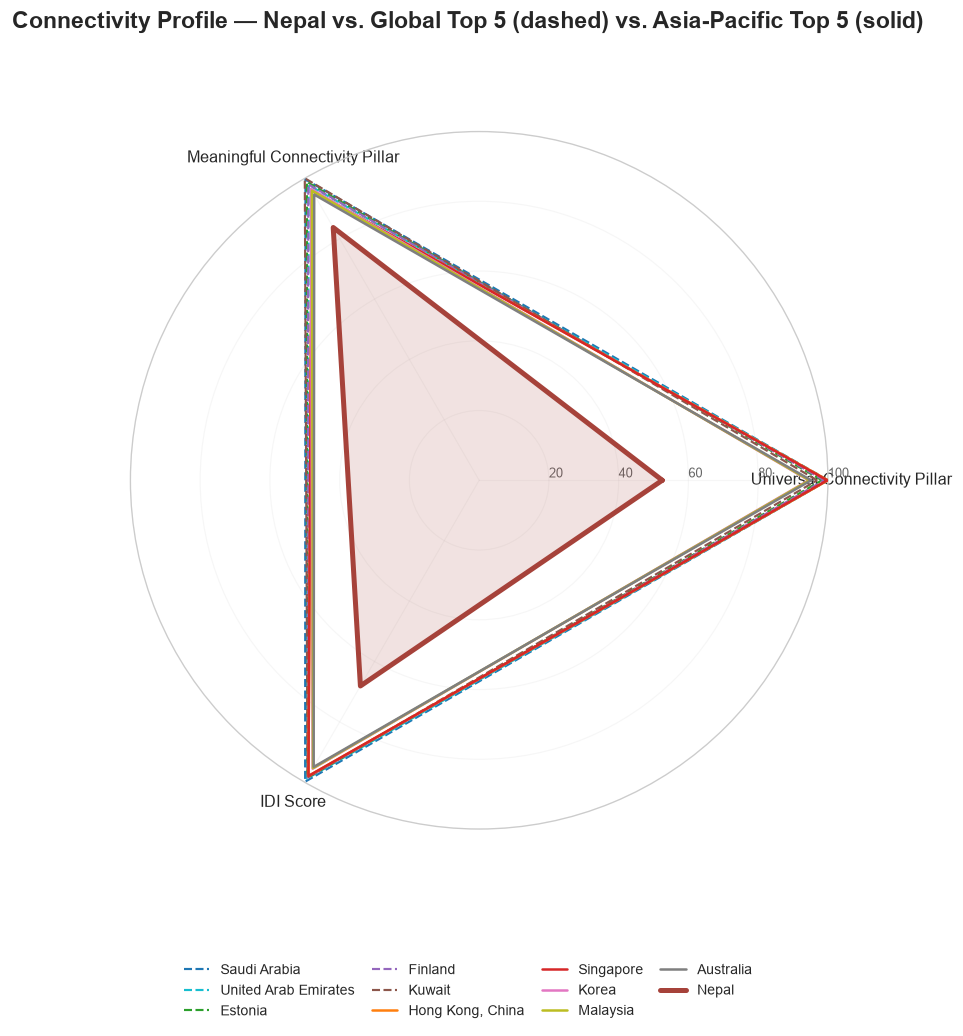

In [12]:
def radar_chart_idi(top_global, top_regional, filename, title):
    labels_disp = [c.replace("_", " ") for c in IDI_PILLARS]
    n = len(IDI_PILLARS)
    angles = np.linspace(0, 2*np.pi, n, endpoint=False).tolist()
    angles += angles[:1]

    fig, ax = plt.subplots(figsize=(7.5, 8.5), subplot_kw=dict(polar=True))
    global_colors = ["#1f77b4", "#17becf", "#2ca02c", "#9467bd", "#8c564b"]
    regional_colors = ["#ff7f0e", "#d62728", "#e377c2", "#bcbd22", "#7f7f7f"]

    def plot_econ(name, color, lw, ls, fill):
        row = idi[idi.Economy == name].iloc[0]
        vals = [row[p] for p in IDI_PILLARS]
        vals += vals[:1]
        ax.plot(angles, vals, color=color, linewidth=lw, linestyle=ls,
                 label=name.split(" (")[0], zorder=3)
        if fill:
            ax.fill(angles, vals, color=color, alpha=0.15, zorder=2)

    for c, color in zip(top_global, global_colors):
        plot_econ(c, color, 1.3, "--", fill=False)
    for c, color in zip(top_regional, regional_colors):
        plot_econ(c, color, 1.5, "-", fill=False)
    plot_econ(NEPAL_ECONOMY, "#A6423A", 3.0, "-", fill=True)

    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(labels_disp, fontsize=9.5)
    ax.set_ylim(0, 100)
    ax.set_rlabel_position(0)
    ax.tick_params(axis="y", labelsize=8, colors="#666666")
    ax.spines["polar"].set_color("#cccccc")
    ax.grid(color="#dddddd", linewidth=0.7)

    fig.suptitle(title, fontsize=13.5, fontweight="bold", y=0.98)
    handles, leg_labels = ax.get_legend_handles_labels()
    fig.legend(handles, leg_labels, loc="lower center", bbox_to_anchor=(0.5, -0.02),
               ncol=4, frameon=False, fontsize=8.5, handlelength=1.8, columnspacing=1.2)
    fig.subplots_adjust(top=0.90, bottom=0.14)
    fig.savefig(FIG_DIR / filename, bbox_inches="tight")
    plt.show()

radar_chart_idi(GLOBAL_TOP5_IDI, REGIONAL_TOP5_IDI, "fig4_idi_radar_top5.png",
                 f"Connectivity Profile — Nepal vs. Global Top 5 (dashed) vs. {nepal_region} Top 5 (solid)")

In [11]:
## 8. Export manuscript-ready tables
def to_markdown_table(dframe: pd.DataFrame) -> str:
    return dframe.to_markdown(index=False)

with open(PROCESSED_DIR / "nepal_idi_scorecard_full_sample.md", "w") as f:
    f.write(to_markdown_table(idi_scorecard))
with open(PROCESSED_DIR / "south_asia_broadband_affordability.md", "w") as f:
    f.write(to_markdown_table(sa_df))

print("Tables written to", PROCESSED_DIR)
print("Figures written to", FIG_DIR)
print(sorted(FIG_DIR.glob("fig*idi*.png")) + sorted(FIG_DIR.glob("fig*affordability*.png")))

Tables written to ..\data\processed
Figures written to ..\outputs\figures
[WindowsPath('../outputs/figures/fig2_idi_score_heatmap.png'), WindowsPath('../outputs/figures/fig3_idi_distributions.png'), WindowsPath('../outputs/figures/fig4_idi_radar_top5.png'), WindowsPath('../outputs/figures/fig1_south_asia_affordability.png')]
